<h1>Importing Libraries</h1>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.autograd as ag
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

<h1> Solution to Lane Emden Equation </h1>

<p> Ignoring at x = 0 (as it is a singularity) </p>

In [2]:
def solution(x):
    with np.errstate(divide="ignore", invalid="ignore"):
        y = np.where(x == 0, 1, np.sin(x) / x)
    return y

<h1>Neural Network Architecture</h1>

<p>Defining the Neural Network Class, which will be called multiple times throughout the program</p>

In [3]:
class NeuralNetwork(nn.Module):
    def __init__(
        self,
        input_size: int = 1,
        output_size: int = 1,
        hidden_layers: int = 5,
        hidden_nodes: int = 10,
    ) -> None:
        super().__init__()

        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList(
            [nn.Linear(hidden_nodes, hidden_nodes)] * hidden_layers
        )
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh()

    def _apply_model(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t

<h1>Generate Training Data</h1>

<h2> Defining Function to Create training points, with number of collocation points as an argument </h2>

In [4]:
def create_training_points(no_colloc_points):
    x = np.linspace(0, 7, 700).reshape(-1, 1)  # Training Points
    y = solution(x).reshape(-1, 1)

    x_data = x[0:300:30]  # Reducing the training points
    y_data = y[0:300:30]

    x_data = torch.tensor(x_data, dtype=torch.float32)
    y_data = torch.tensor(y_data, dtype=torch.float32)

    x_physics = torch.linspace(
        0, 7, no_colloc_points, requires_grad=True, dtype=torch.float32
    ).reshape(-1, 1)  # Collocation Points
    return x_data, y_data, x_physics

<h1>Hyperparameters and Training (Without Physics Loss)</h1>

In [5]:
EPOCHS = 20000
LR = 3e-3

model = NeuralNetwork(hidden_layers=1, hidden_nodes=32)
optim = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=1000)
data_loss = nn.MSELoss()
x_data, y_data, x_physics = create_training_points(20)

for epoch in range(EPOCHS):
    optim.zero_grad()

    y_pred = model(x_data)  # Predicting training data
    loss_y = data_loss(y_pred, y_data)  # Calulating normal MSE Loss

    loss = loss_y

    loss.backward()
    optim.step()
    scheduler.step(loss)

    if epoch % 1000 == 0:
        print(f"Epochs = {epoch} of {EPOCHS}, Loss = {float(loss):.4e}")

/usr/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /build/python-pytorch/src/pytorch-opt/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epochs = 0 of 20000, Loss = 5.6978e-01
Epochs = 1000 of 20000, Loss = 2.6045e-06
Epochs = 2000 of 20000, Loss = 1.1380e-06
Epochs = 3000 of 20000, Loss = 3.0666e-07
Epochs = 4000 of 20000, Loss = 6.7071e-08
Epochs = 5000 of 20000, Loss = 4.1569e-08
Epochs = 6000 of 20000, Loss = 4.9808e-08
Epochs = 7000 of 20000, Loss = 4.4772e-08
Epochs = 8000 of 20000, Loss = 4.4193e-08
Epochs = 9000 of 20000, Loss = 4.4160e-08
Epochs = 10000 of 20000, Loss = 4.4157e-08
Epochs = 11000 of 20000, Loss = 4.4157e-08
Epochs = 12000 of 20000, Loss = 4.4157e-08
Epochs = 13000 of 20000, Loss = 4.4157e-08
Epochs = 14000 of 20000, Loss = 4.4157e-08
Epochs = 15000 of 20000, Loss = 4.4157e-08
Epochs = 16000 of 20000, Loss = 4.4151e-08
Epochs = 17000 of 20000, Loss = 4.4156e-08
Epochs = 18000 of 20000, Loss = 4.4154e-08
Epochs = 19000 of 20000, Loss = 4.4155e-08


In [6]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().numpy().reshape(-1, 1)

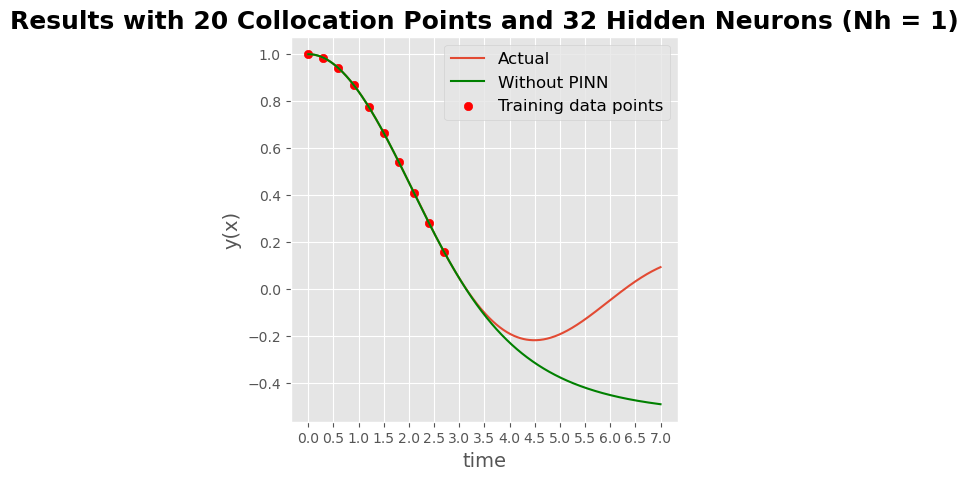

In [7]:
title_font = {"fontsize": 18, "fontweight": "bold"}

plt.figure(figsize=(5, 5))
plt.style.use("ggplot")
plt.xticks(np.arange(0, 7.5, step=0.5))
plt.title(
    "Results with 20 Collocation Points and 32 Hidden Neurons (Nh = 1)", title_font
)
plt.plot(x, y, label="Actual")
plt.xlabel("time", fontsize=14)
plt.plot(x, y_pred, label="Without PINN", c="g")
plt.ylabel("y(x)", fontsize=14)
plt.scatter(
    x_data.reshape(
        -1,
    ),
    y_data.reshape(
        -1,
    ),
    c="r",
    label="Training data points",
)
plt.legend(fontsize="large")
plt.show()

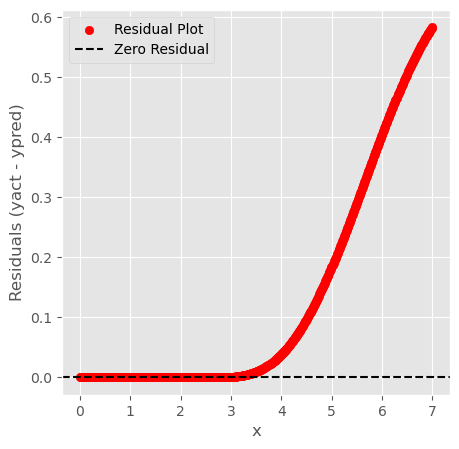

In [8]:
residuals = y - y_pred
plt.figure(figsize=(5, 5))
plt.scatter(x, residuals, color="r", label="Residual Plot")
plt.axhline(y=0, color="k", linestyle="--", label="Zero Residual")
plt.xlabel("x")
plt.ylabel("Residuals (yact - ypred)")
plt.legend()
plt.show()

In [9]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

0.05109253620384177


<h1>Hyperparamters and Training (With Physics Loss)<h1>

<h1> Defining PINN Model<h1>

In [10]:
def create_pinn_model(no_hidden_layer, no_hidden_node, no_of_colloc):
    EPOCHS = 20000
    LR = 3e-3

    model = NeuralNetwork(hidden_layers=no_hidden_layer, hidden_nodes=no_hidden_node)
    optim = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=1000)
    data_loss = nn.MSELoss()
    x_data, y_data, x_physics = create_training_points(no_of_colloc)

    for epoch in range(EPOCHS):
        optim.zero_grad()

        # Compute the "data loss"
        y_pred = model(x_data)
        loss_y = data_loss(y_pred, y_data)

        # Compute the Derivates of the model WRT inputs
        u = model(x_physics)
        du = ag.grad(u, x_physics, torch.ones_like(u), create_graph=True)[0]
        ddu = ag.grad(du, x_physics, torch.ones_like(du), create_graph=True)[0]

        # BC condition on x=0
        loss_y = loss_y + 0.01 * (du[0] ** 2)

        # Compute the physics loss
        physics = x_physics * ddu + 2 * du + u * x_physics
        loss_f = torch.mean(physics**2)

        # backpropagate joint loss
        loss = loss_y + loss_f  # add two loss terms together with equal weight
        loss.backward()
        optim.step()
        scheduler.step(loss)

        if epoch % 1000 == 0:
            print(f"Epochs = {epoch} of {EPOCHS}, Loss = {float(loss):.4e}")
    return model

In [11]:
model = create_pinn_model(1, 32, 20)

Epochs = 0 of 20000, Loss = 1.2524e+00
Epochs = 1000 of 20000, Loss = 1.3281e-02
Epochs = 2000 of 20000, Loss = 3.6110e-03
Epochs = 3000 of 20000, Loss = 8.0719e-04
Epochs = 4000 of 20000, Loss = 1.0795e-02
Epochs = 5000 of 20000, Loss = 3.6528e-04
Epochs = 6000 of 20000, Loss = 4.1535e-04
Epochs = 7000 of 20000, Loss = 1.8115e-04
Epochs = 8000 of 20000, Loss = 1.2341e-04
Epochs = 9000 of 20000, Loss = 7.9810e-05
Epochs = 10000 of 20000, Loss = 5.1108e-05
Epochs = 11000 of 20000, Loss = 3.5589e-05
Epochs = 12000 of 20000, Loss = 2.0281e-05
Epochs = 13000 of 20000, Loss = 1.8274e-05
Epochs = 14000 of 20000, Loss = 1.2006e-05
Epochs = 15000 of 20000, Loss = 5.5056e-05
Epochs = 16000 of 20000, Loss = 5.0722e-06
Epochs = 17000 of 20000, Loss = 6.1154e-06
Epochs = 18000 of 20000, Loss = 6.0551e-06
Epochs = 19000 of 20000, Loss = 3.6448e-04


In [12]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
no_of_colloc = 20
x_data, y_data, x_physics = create_training_points(no_of_colloc)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [13]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

3.1242587088735495e-09


In [14]:
def create_graph_1(
    no_colloc_points,
    no_of_neuron,
    no_of_hidden_layer,
    x,
    x_data,
    y,
    y_data,
    y_prediction,
):

    title_font = {"fontsize": 18, "fontweight": "bold"}

    plt.figure(figsize=(5, 5))
    plt.style.use("ggplot")
    plt.xticks(np.arange(0, 7.5, step=0.5))
    plt.title(
        f"{no_colloc_points} Collocation Points,{no_of_neuron} Neurons each in {no_of_hidden_layer} hidden layer",
        title_font,
    )
    plt.plot(x, y, label="Actual")
    plt.xlabel("time", fontsize=14)
    plt.plot(x, y_prediction, label="PINN", c="g")
    plt.ylabel("u(t)", fontsize=14)
    plt.scatter(
        x_data.reshape(
            -1,
        ),
        y_data.reshape(
            -1,
        ),
        c="r",
        label="Training data points",
    )
    plt.legend(fontsize="large")
    plt.show()

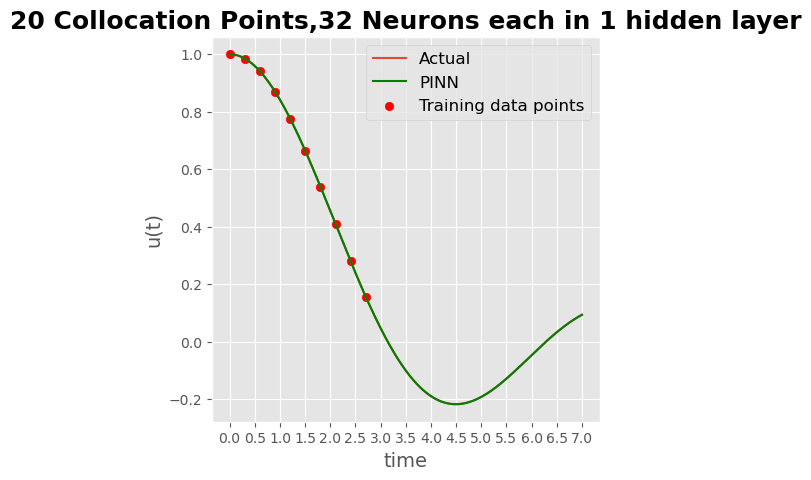

In [15]:
create_graph_1(20, 32, 1, x, x_data, y, y_data, y_pred)

In [16]:
def create_graph_2(x, y_prediction):
    residuals = y - y_prediction
    plt.figure(figsize=(5, 5))
    plt.scatter(x, residuals, color="r", label="Residual Plot")
    plt.axhline(y=0, color="k", linestyle="--", label="Zero Residual")
    plt.xlabel("x")
    plt.ylabel("Residuals (yact - ypred)")
    plt.legend()
    plt.show()

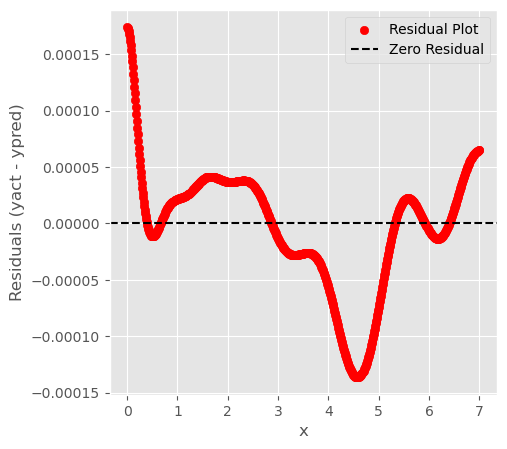

In [17]:
create_graph_2(x, y_pred)

<h1> From the above results, PINNs obviously generate better results when dealing with differential equations, however we can also analyse the effect of architecture on results of PINNs<h1>



<h1> 2. Varying the number of neurons in each layer

<h1> 2.1 Nh = 1, N = 16, Nc= 20 </h1>

In [18]:
model = create_pinn_model(1, 16, 20)

Epochs = 0 of 20000, Loss = 1.3697e+00
Epochs = 1000 of 20000, Loss = 8.2626e-03
Epochs = 2000 of 20000, Loss = 7.2709e-04
Epochs = 3000 of 20000, Loss = 3.1853e-04
Epochs = 4000 of 20000, Loss = 2.1398e-04
Epochs = 5000 of 20000, Loss = 1.4811e-04
Epochs = 6000 of 20000, Loss = 1.1514e-04
Epochs = 7000 of 20000, Loss = 8.8422e-05
Epochs = 8000 of 20000, Loss = 6.5607e-04
Epochs = 9000 of 20000, Loss = 6.1845e-05
Epochs = 10000 of 20000, Loss = 4.4473e-05
Epochs = 11000 of 20000, Loss = 3.6192e-05
Epochs = 12000 of 20000, Loss = 2.6671e-05
Epochs = 13000 of 20000, Loss = 5.4825e-05
Epochs = 14000 of 20000, Loss = 2.0406e-05
Epochs = 15000 of 20000, Loss = 1.5195e-05
Epochs = 16000 of 20000, Loss = 7.0982e-04
Epochs = 17000 of 20000, Loss = 1.5411e-05
Epochs = 18000 of 20000, Loss = 1.2807e-05
Epochs = 19000 of 20000, Loss = 1.2340e-05


In [19]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [20]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

1.367750881209948e-08


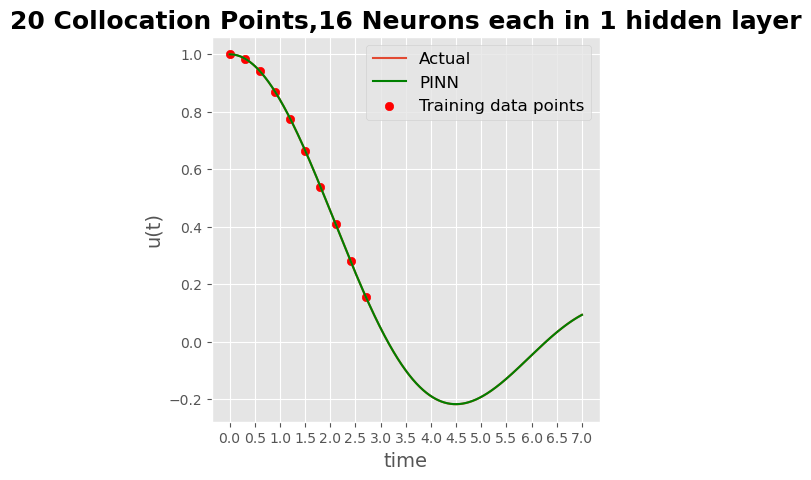

In [21]:
create_graph_1(20, 16, 1, x, x_data, y, y_data, y_pred)

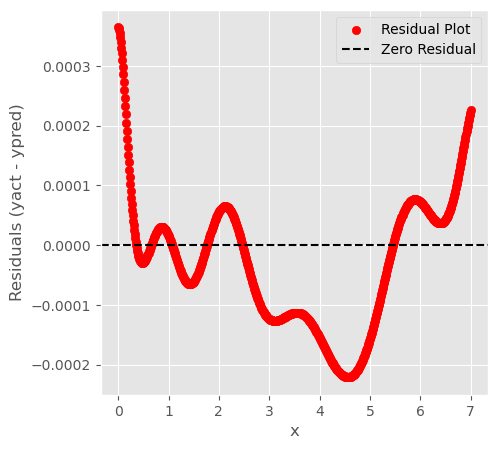

In [22]:
create_graph_2(x, y_pred)

<h1> 2.2 Nh = 1, N = 20, Nc= 20 </h1>

In [23]:
model = create_pinn_model(1, 20, 20)

Epochs = 0 of 20000, Loss = 8.3762e-01
Epochs = 1000 of 20000, Loss = 1.4111e-02
Epochs = 2000 of 20000, Loss = 1.1341e-02
Epochs = 3000 of 20000, Loss = 1.0674e-02
Epochs = 4000 of 20000, Loss = 7.5192e-03
Epochs = 5000 of 20000, Loss = 5.2827e-03
Epochs = 6000 of 20000, Loss = 3.0026e-03
Epochs = 7000 of 20000, Loss = 2.0549e-03
Epochs = 8000 of 20000, Loss = 1.5321e-03
Epochs = 9000 of 20000, Loss = 1.2698e-03
Epochs = 10000 of 20000, Loss = 1.1399e-03
Epochs = 11000 of 20000, Loss = 6.7580e-04
Epochs = 12000 of 20000, Loss = 6.2130e-04
Epochs = 13000 of 20000, Loss = 5.3183e-04
Epochs = 14000 of 20000, Loss = 4.4999e-04
Epochs = 15000 of 20000, Loss = 4.7779e-04
Epochs = 16000 of 20000, Loss = 6.0637e-04
Epochs = 17000 of 20000, Loss = 2.5364e-02
Epochs = 18000 of 20000, Loss = 2.2350e-02
Epochs = 19000 of 20000, Loss = 1.5712e-04


In [24]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [25]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

1.5720943136541101e-06


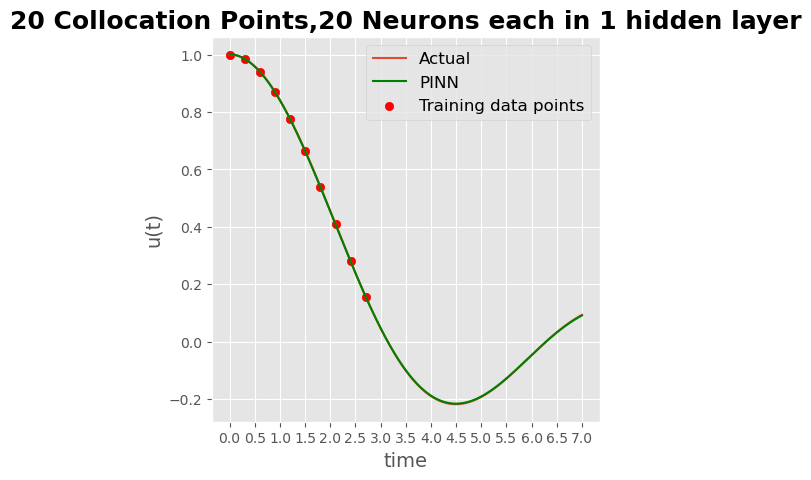

In [26]:
create_graph_1(20, 20, 1, x, x_data, y, y_data, y_pred)

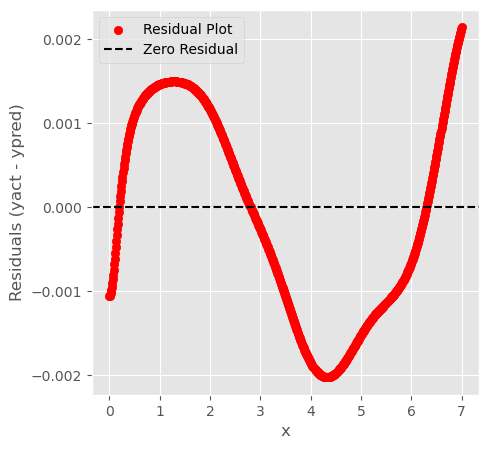

In [27]:
create_graph_2(x, y_pred)

<h1> 2.3 Nh = 1, N = 24, Nc= 20 </h1>

In [28]:
model = create_pinn_model(1, 24, 20)

Epochs = 0 of 20000, Loss = 6.9165e-01
Epochs = 1000 of 20000, Loss = 7.1944e-03
Epochs = 2000 of 20000, Loss = 1.3462e-03
Epochs = 3000 of 20000, Loss = 6.5909e-04
Epochs = 4000 of 20000, Loss = 3.5834e-04
Epochs = 5000 of 20000, Loss = 2.2101e-04
Epochs = 6000 of 20000, Loss = 1.4455e-04
Epochs = 7000 of 20000, Loss = 9.5569e-05
Epochs = 8000 of 20000, Loss = 6.2542e-05
Epochs = 9000 of 20000, Loss = 3.9471e-05
Epochs = 10000 of 20000, Loss = 2.3845e-05
Epochs = 11000 of 20000, Loss = 1.6569e-05
Epochs = 12000 of 20000, Loss = 1.2101e-05
Epochs = 13000 of 20000, Loss = 1.9269e-04
Epochs = 14000 of 20000, Loss = 5.3468e-06
Epochs = 15000 of 20000, Loss = 4.3219e-06
Epochs = 16000 of 20000, Loss = 7.5899e-06
Epochs = 17000 of 20000, Loss = 9.1181e-06
Epochs = 18000 of 20000, Loss = 5.8493e-05
Epochs = 19000 of 20000, Loss = 4.2057e-06


In [29]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [30]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

6.480173607136146e-09


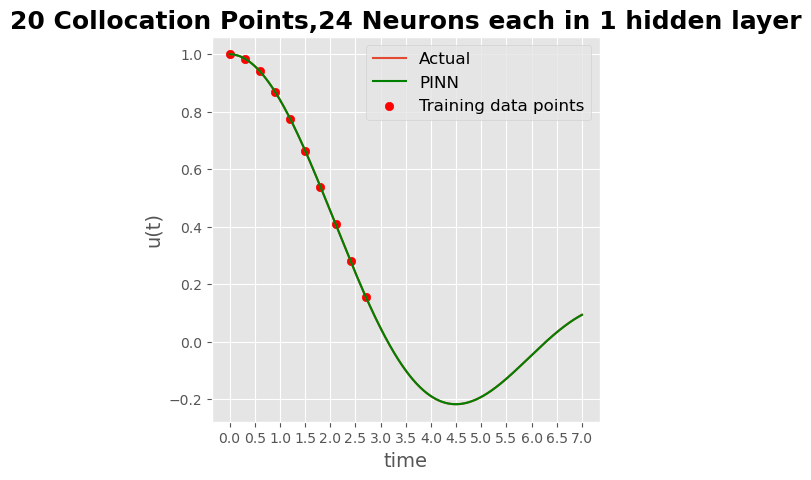

In [31]:
create_graph_1(20, 24, 1, x, x_data, y, y_data, y_pred)

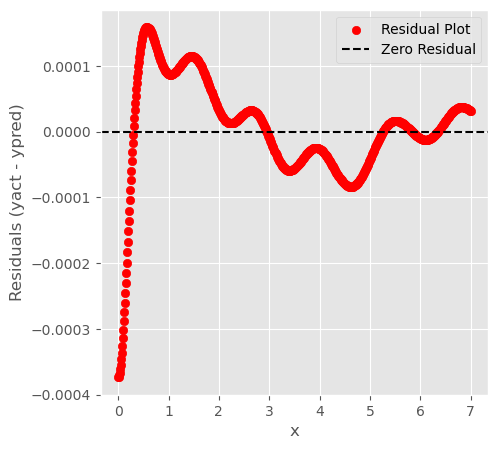

In [32]:
create_graph_2(x, y_pred)

<h1> 2.4 Nh = 1, N = 28, Nc= 20 </h1>

In [33]:
model = create_pinn_model(1, 28, 20)

Epochs = 0 of 20000, Loss = 6.3243e-01
Epochs = 1000 of 20000, Loss = 1.2243e-02
Epochs = 2000 of 20000, Loss = 1.2012e-03
Epochs = 3000 of 20000, Loss = 4.0400e-04
Epochs = 4000 of 20000, Loss = 8.3941e-04
Epochs = 5000 of 20000, Loss = 2.6953e-05
Epochs = 6000 of 20000, Loss = 2.6173e-05
Epochs = 7000 of 20000, Loss = 2.1705e-05
Epochs = 8000 of 20000, Loss = 2.2794e-05
Epochs = 9000 of 20000, Loss = 2.1838e-05
Epochs = 10000 of 20000, Loss = 1.9118e-05
Epochs = 11000 of 20000, Loss = 1.6027e-05
Epochs = 12000 of 20000, Loss = 1.3064e-05
Epochs = 13000 of 20000, Loss = 2.7748e-03
Epochs = 14000 of 20000, Loss = 1.3557e-03
Epochs = 15000 of 20000, Loss = 6.6470e-06
Epochs = 16000 of 20000, Loss = 5.0582e-06
Epochs = 17000 of 20000, Loss = 3.4890e-06
Epochs = 18000 of 20000, Loss = 3.3702e-06
Epochs = 19000 of 20000, Loss = 2.5630e-06


In [34]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [35]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

4.825004093646488e-10


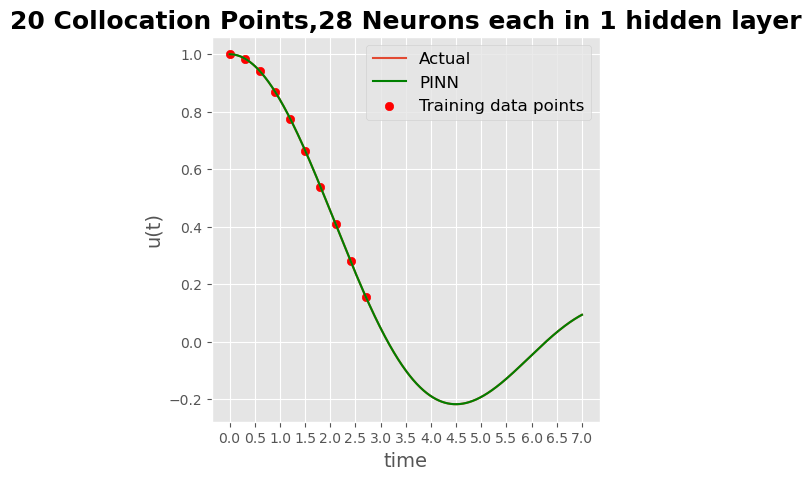

In [36]:
create_graph_1(20, 28, 1, x, x_data, y, y_data, y_pred)

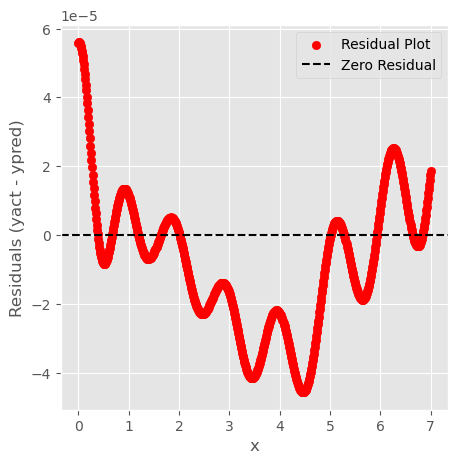

In [37]:
create_graph_2(x, y_pred)

<h1>2.5 Conclusion</h1>

20 Collocation points, 1 Hidden Layer:

<ul>
<li>16 Neurons: 5.327446387710545e-07</li>
<li>20 Neurons: 2.455681358444268e-08</li>
<li>24 Neurons: 2.7053212988187934e-09</li>
<li>28 Neurons: 4.4787253478173595e-07</li>
</ul>

Therefore, 24 neurons seems to the better option. So we'll continue with 24 Neurons

<h1> 3. Varying the number of collocation points </h1>

<h1>3.1 Nh = 1, N = 24, Nc= 10<h1>

In [38]:
model = create_pinn_model(1, 24, 10)

Epochs = 0 of 20000, Loss = 9.6704e-01
Epochs = 1000 of 20000, Loss = 1.3531e-02
Epochs = 2000 of 20000, Loss = 4.8306e-04
Epochs = 3000 of 20000, Loss = 3.8076e-06
Epochs = 4000 of 20000, Loss = 1.4909e-06
Epochs = 5000 of 20000, Loss = 1.9313e-07
Epochs = 6000 of 20000, Loss = 7.0310e-08
Epochs = 7000 of 20000, Loss = 4.5014e-08
Epochs = 8000 of 20000, Loss = 5.5875e-08
Epochs = 9000 of 20000, Loss = 6.7017e-08
Epochs = 10000 of 20000, Loss = 6.2015e-08
Epochs = 11000 of 20000, Loss = 6.1512e-08
Epochs = 12000 of 20000, Loss = 6.1482e-08
Epochs = 13000 of 20000, Loss = 6.1474e-08
Epochs = 14000 of 20000, Loss = 6.1472e-08
Epochs = 15000 of 20000, Loss = 6.1472e-08
Epochs = 16000 of 20000, Loss = 6.1472e-08
Epochs = 17000 of 20000, Loss = 6.1472e-08
Epochs = 18000 of 20000, Loss = 6.1471e-08
Epochs = 19000 of 20000, Loss = 6.1467e-08


In [39]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [40]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

5.928566783494317e-08


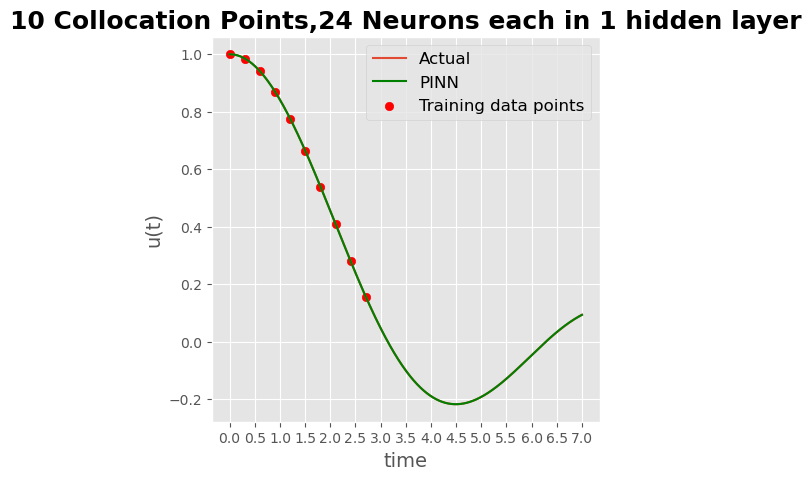

In [41]:
create_graph_1(10, 24, 1, x, x_data, y, y_data, y_pred)

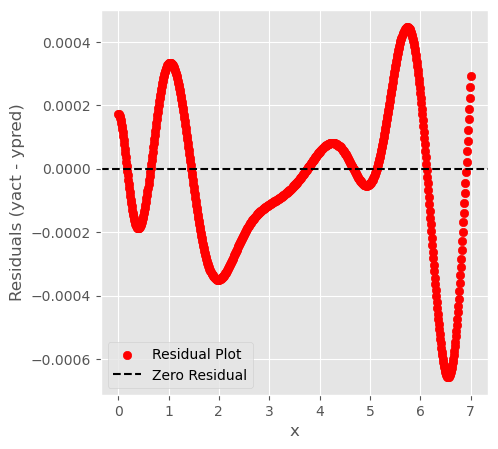

In [42]:
create_graph_2(x, y_pred)

<h1>3.2 Nh = 1, N = 24, Nc= 15<h1>

In [43]:
model = create_pinn_model(1, 24, 15)

Epochs = 0 of 20000, Loss = 1.1435e+00
Epochs = 1000 of 20000, Loss = 5.8646e-03
Epochs = 2000 of 20000, Loss = 2.1009e-03
Epochs = 3000 of 20000, Loss = 9.4473e-04
Epochs = 4000 of 20000, Loss = 5.0601e-04
Epochs = 5000 of 20000, Loss = 3.1280e-04
Epochs = 6000 of 20000, Loss = 3.4054e-04
Epochs = 7000 of 20000, Loss = 1.9457e-04
Epochs = 8000 of 20000, Loss = 2.5841e-04
Epochs = 9000 of 20000, Loss = 1.1027e-04
Epochs = 10000 of 20000, Loss = 8.3199e-05
Epochs = 11000 of 20000, Loss = 2.9508e-05
Epochs = 12000 of 20000, Loss = 1.6183e-05
Epochs = 13000 of 20000, Loss = 1.4555e-05
Epochs = 14000 of 20000, Loss = 1.4817e-05
Epochs = 15000 of 20000, Loss = 1.1271e-05
Epochs = 16000 of 20000, Loss = 8.9258e-06
Epochs = 17000 of 20000, Loss = 6.4714e-06
Epochs = 18000 of 20000, Loss = 4.6568e-06
Epochs = 19000 of 20000, Loss = 3.3098e-06


In [44]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [45]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

5.5728111201166676e-09


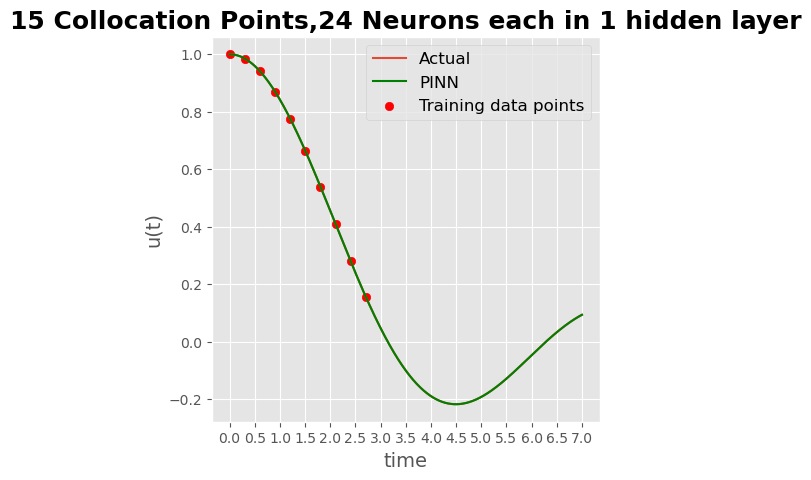

In [46]:
create_graph_1(15, 24, 1, x, x_data, y, y_data, y_pred)

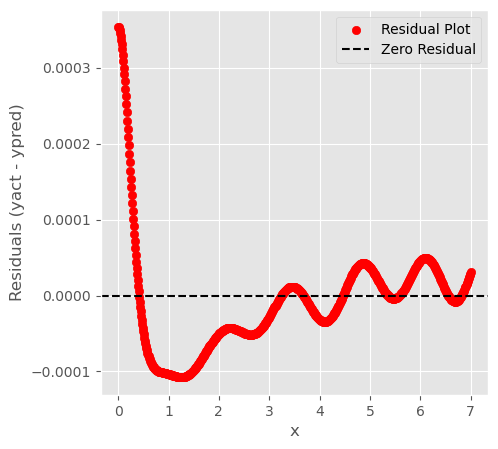

In [47]:
create_graph_2(x, y_pred)

<h1>3.3 Nh = 1, N = 24, Nc= 25<h1>

In [48]:
model = create_pinn_model(1, 24, 25)

Epochs = 0 of 20000, Loss = 6.2502e-01
Epochs = 1000 of 20000, Loss = 2.0900e-03
Epochs = 2000 of 20000, Loss = 6.5634e-04
Epochs = 3000 of 20000, Loss = 2.8140e-04
Epochs = 4000 of 20000, Loss = 1.5624e-04
Epochs = 5000 of 20000, Loss = 7.8956e-05
Epochs = 6000 of 20000, Loss = 5.3353e-05
Epochs = 7000 of 20000, Loss = 3.6442e-05
Epochs = 8000 of 20000, Loss = 2.4292e-05
Epochs = 9000 of 20000, Loss = 2.2756e-03
Epochs = 10000 of 20000, Loss = 5.9996e-05
Epochs = 11000 of 20000, Loss = 1.0634e-05
Epochs = 12000 of 20000, Loss = 6.4243e-06
Epochs = 13000 of 20000, Loss = 1.2346e-03
Epochs = 14000 of 20000, Loss = 7.9410e-04
Epochs = 15000 of 20000, Loss = 8.6913e-06
Epochs = 16000 of 20000, Loss = 7.2721e-05
Epochs = 17000 of 20000, Loss = 2.6317e-06
Epochs = 18000 of 20000, Loss = 2.6788e-06
Epochs = 19000 of 20000, Loss = 2.7222e-06


In [49]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [50]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

1.2152521206770333e-09


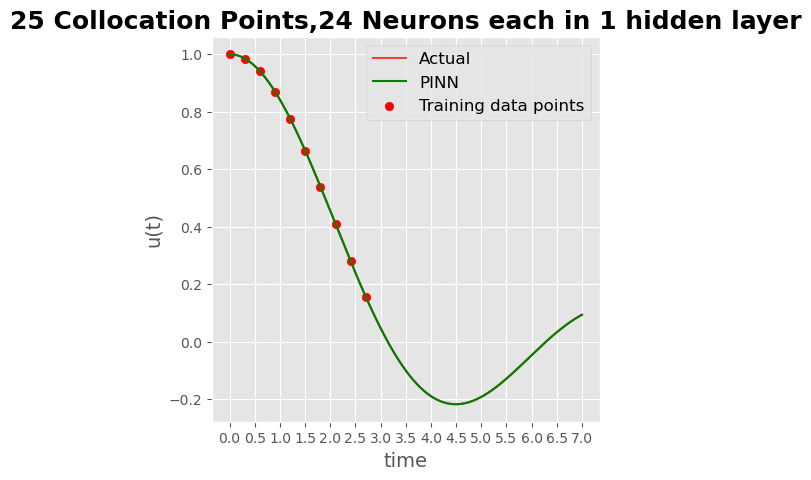

In [51]:
create_graph_1(25, 24, 1, x, x_data, y, y_data, y_pred)

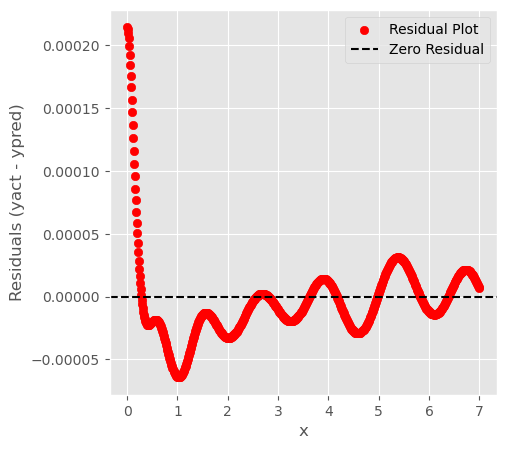

In [52]:
create_graph_2(x, y_pred)

<h1>3.4 Conclusion </h1>


24 Neurons, 1 Hidden Layer:

<ul>
<li>10 Neurons: 1.9872757342093745e-08</li>
<li>15 Neurons: 2.9754251113567395e-08</li>
<li>20 Neurons: 2.7053212988187934e-09</li>
<li>24 Neurons: 4.957080298011296e-07</li>
</ul>

Therefore, 20 collocation points to the better option. So we'll continue with 20 Collocation points.

<h1>4. Varying the number of hidden layers</h1>

<h1>4.1 Nh = 3, N = 24, Nc= 20</h1>

In [53]:
model = create_pinn_model(3, 24, 20)

Epochs = 0 of 20000, Loss = 6.2552e-01
Epochs = 1000 of 20000, Loss = 1.2559e-02
Epochs = 2000 of 20000, Loss = 5.2945e-04
Epochs = 3000 of 20000, Loss = 1.4960e-04
Epochs = 4000 of 20000, Loss = 3.7571e-05
Epochs = 5000 of 20000, Loss = 9.4805e-04
Epochs = 6000 of 20000, Loss = 8.8630e-06
Epochs = 7000 of 20000, Loss = 7.9577e-06
Epochs = 8000 of 20000, Loss = 7.8591e-06
Epochs = 9000 of 20000, Loss = 7.8499e-06
Epochs = 10000 of 20000, Loss = 7.8499e-06
Epochs = 11000 of 20000, Loss = 7.8495e-06
Epochs = 12000 of 20000, Loss = 7.8498e-06
Epochs = 13000 of 20000, Loss = 7.8498e-06
Epochs = 14000 of 20000, Loss = 7.8496e-06
Epochs = 15000 of 20000, Loss = 7.8496e-06
Epochs = 16000 of 20000, Loss = 7.8495e-06
Epochs = 17000 of 20000, Loss = 7.8497e-06
Epochs = 18000 of 20000, Loss = 7.8497e-06
Epochs = 19000 of 20000, Loss = 7.8493e-06


In [54]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [55]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

4.77855132204093e-09


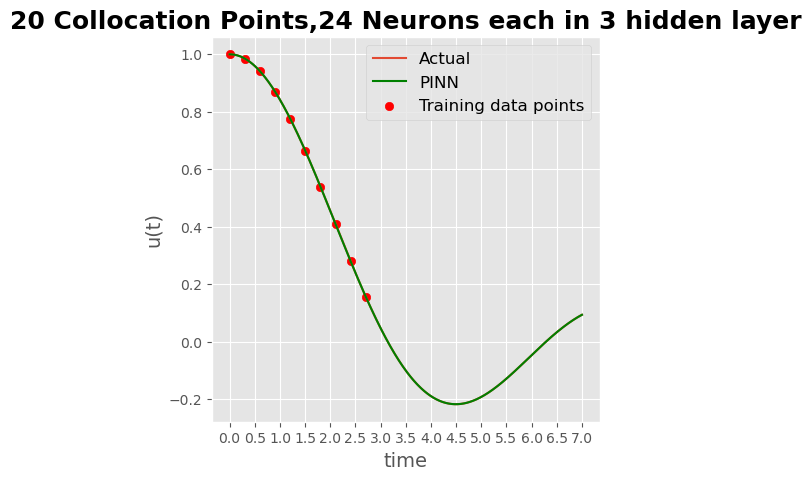

In [56]:
create_graph_1(20, 24, 3, x, x_data, y, y_data, y_pred)

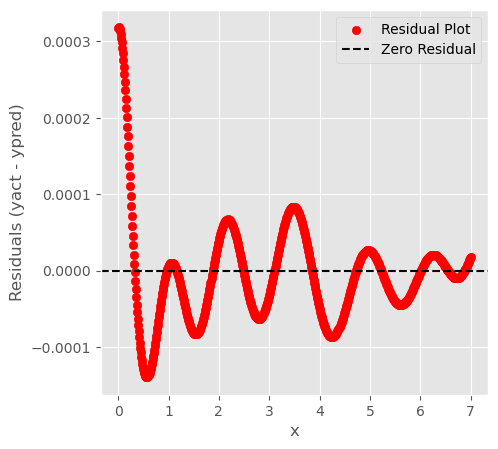

In [57]:
create_graph_2(x, y_pred)

<h1>4.2 Nh = 5, N = 24, Nc= 20</h1>

In [58]:
model = create_pinn_model(5, 24, 20)

Epochs = 0 of 20000, Loss = 5.0483e-01
Epochs = 1000 of 20000, Loss = 5.6347e-03
Epochs = 2000 of 20000, Loss = 2.6781e-05
Epochs = 3000 of 20000, Loss = 7.3177e-05
Epochs = 4000 of 20000, Loss = 1.1318e-04
Epochs = 5000 of 20000, Loss = 1.7117e-05
Epochs = 6000 of 20000, Loss = 2.6501e-05
Epochs = 7000 of 20000, Loss = 4.9242e-04
Epochs = 8000 of 20000, Loss = 3.6311e-04
Epochs = 9000 of 20000, Loss = 3.8977e-04
Epochs = 10000 of 20000, Loss = 1.5030e-05
Epochs = 11000 of 20000, Loss = 1.9307e-06
Epochs = 12000 of 20000, Loss = 1.4562e-06
Epochs = 13000 of 20000, Loss = 1.2688e-06
Epochs = 14000 of 20000, Loss = 1.5819e-06
Epochs = 15000 of 20000, Loss = 2.2947e-04
Epochs = 16000 of 20000, Loss = 8.2684e-04
Epochs = 17000 of 20000, Loss = 2.1880e-05
Epochs = 18000 of 20000, Loss = 3.8646e-07
Epochs = 19000 of 20000, Loss = 2.6650e-07


In [59]:
model.eval()
x = np.linspace(0, 7, 700).reshape(-1, 1)
y = solution(x).reshape(-1, 1)
x_data, y_data, x_physics = create_training_points(20)
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [60]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

1.3176730268997785e-09


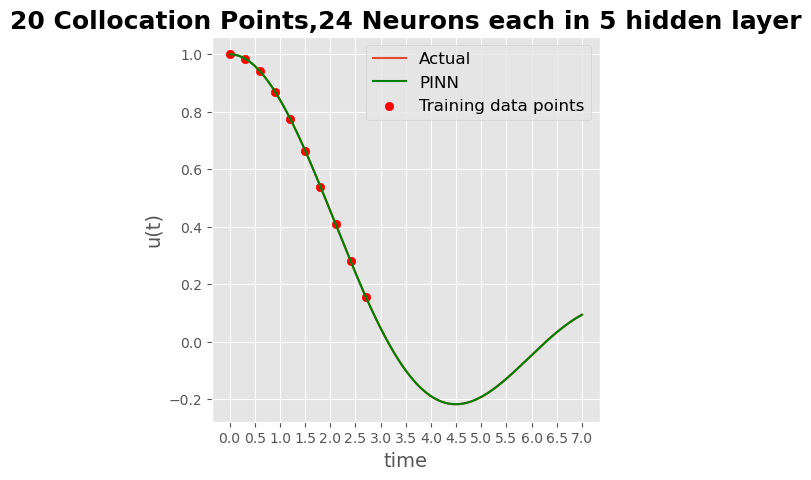

In [61]:
create_graph_1(20, 24, 5, x, x_data, y, y_data, y_pred)

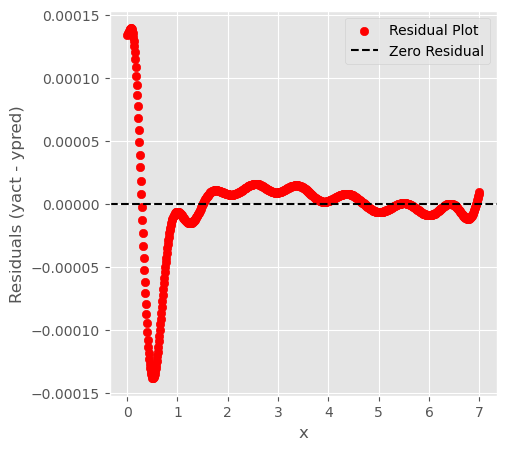

In [62]:
create_graph_2(x, y_pred)

<h1>4.3 Conclusion</h1>

24 Neurons, 20 Collocation Points:

<ul>
<li>1 Hidden Layer: 2.7053212988187934e-09</li>
<li>3 Hidden Layer: 1.4546934787238253e-07</li>
<li>5 Hidden Layer: 4.652337317941582e-11</li>
</ul>

Therefore, 5 hidden layers seems to the better option. So we'll continue with 5 hidden layers.

<h1>Best Possible Architecture</h1>

1.   Number Of Collocation Points - 20
2.   Number Of Neurons in Each Layer - 24
3.   Number Of Hidden Layers - 5

<b>Error - 4.652337317941582e-11</b>



<h1>5. New Trainable Parameter</h1>

<p> Till Now the combined loss function was loss = loss_p + loss_d where loss_p
denotes physical loss (collocation points) and loss_d denotes MSE loss (training points).</p>

<p> What we can do is introduce a trainable parameter k such that the new loss function is loss = k*loss_p + loss_d, that is we are varying the weight given to physical loss to determine how much importance it should be given.</p>

In [63]:
x = np.linspace(0, 7, 700).reshape(-1, 1)  # Training Points
y = solution(x).reshape(-1, 1)

x_data = x[0:300:30]  # Reducing the training points
y_data = y[0:300:30]

x_data = torch.tensor(x_data, dtype=torch.float32)
y_data = torch.tensor(y_data, dtype=torch.float32)

x_physics = torch.linspace(0, 7, 20, requires_grad=True, dtype=torch.float32).reshape(
    -1, 1
)  # Collocation Points

In [64]:
EPOCHS = 20000
LR = 3e-3

k = nn.Parameter(torch.tensor(1.0))  # Trainable Parameter
model = NeuralNetwork(hidden_layers=5, hidden_nodes=24)
optim = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=1000)
data_loss = nn.MSELoss()
k_values = []
losses = []

k_range = torch.linspace(0.1, 2.0, 20)

for k_value in k_range:
    k.data.fill_(k_value)  # Set the current k value

    for epoch in range(EPOCHS):
        optim.zero_grad()

        # Compute the "data loss"
        y_pred = model(x_data)
        loss_y = data_loss(y_pred, y_data)

        # Compute the Derivates of the model WRT inputs
        u = model(x_physics)
        du = ag.grad(u, x_physics, torch.ones_like(u), create_graph=True)[0]
        ddu = ag.grad(du, x_physics, torch.ones_like(du), create_graph=True)[0]

        # BC condition on x=0
        loss_y = loss_y + 0.01 * (du[0] ** 2)

        # Compute the physics loss with k
        physics = x_physics * ddu + 2 * du + u * x_physics
        loss_f = torch.mean(physics**2)

        # Backpropagate joint loss
        loss = loss_y + k * loss_f
        loss.backward()
        optim.step()
        scheduler.step(loss)

    # Track the loss and the corresponding k value
    k_values.append(k_value)
    losses.append(loss.item())

# Find the k value with the lowest loss
best_k = k_values[losses.index(min(losses))]

print("Best k:", best_k)
print("Lowest loss:", min(losses))

Best k: tensor(0.1000)
Lowest loss: 1.6728697573853424e-06





<p>Therefore k = 0.1 gives the lowest error. We can test this on our model and find the error.</p>

<h1>6. Final Model </h1>

<ul>
<li> Neurons: 24 </li>
<li> Hidden Layers: 5</li>
<li> Collocation Points: 20</li>
<li> k = 0.1 </li>
</ul>

Let's test this hyperparameters and calculate the final error.

In [65]:
x = np.linspace(0, 7, 700).reshape(-1, 1)  # Training Points
y = solution(x).reshape(-1, 1)

x_data = x[0:300:30]  # Reducing the training points
y_data = y[0:300:30]

x_data = torch.tensor(x_data, dtype=torch.float32)
y_data = torch.tensor(y_data, dtype=torch.float32)

x_physics = torch.linspace(0, 7, 20, requires_grad=True, dtype=torch.float32).reshape(
    -1, 1
)  # Collocation Points

In [66]:
EPOCHS = 20000
LR = 3e-3

model = NeuralNetwork(hidden_layers=5, hidden_nodes=24)
optim = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=1000)
data_loss = nn.MSELoss()

for epoch in range(EPOCHS):
    optim.zero_grad()

    # Compute the "data loss"
    y_pred = model(x_data)
    loss_y = data_loss(y_pred, y_data)

    # Compute the Derivates of the model WRT inputs
    u = model(x_physics)
    du = ag.grad(u, x_physics, torch.ones_like(u), create_graph=True)[0]
    ddu = ag.grad(du, x_physics, torch.ones_like(du), create_graph=True)[0]

    # BC condition on x=0
    loss_y = loss_y + 0.01 * (du[0] ** 2)

    # Compute the physics loss
    physics = x_physics * ddu + 2 * du + u * x_physics
    loss_f = torch.mean(physics**2)

    # backpropagate joint loss
    loss = (
        loss_y + 0.1 * loss_f
    )  # add two loss terms together with more weight to physics loss
    loss.backward()
    optim.step()
    scheduler.step(loss)

    if epoch % 1000 == 0:
        print(f"Epochs = {epoch} of {EPOCHS}, Loss = {float(loss):.4e}")

Epochs = 0 of 20000, Loss = 3.4869e-01
Epochs = 1000 of 20000, Loss = 4.8739e-04
Epochs = 2000 of 20000, Loss = 1.1378e-04
Epochs = 3000 of 20000, Loss = 3.2603e-05
Epochs = 4000 of 20000, Loss = 1.1716e-06
Epochs = 5000 of 20000, Loss = 1.4615e-04
Epochs = 6000 of 20000, Loss = 1.0741e-06
Epochs = 7000 of 20000, Loss = 1.0502e-06
Epochs = 8000 of 20000, Loss = 1.0467e-06
Epochs = 9000 of 20000, Loss = 1.0464e-06
Epochs = 10000 of 20000, Loss = 1.0464e-06
Epochs = 11000 of 20000, Loss = 1.0464e-06
Epochs = 12000 of 20000, Loss = 1.0464e-06
Epochs = 13000 of 20000, Loss = 1.0465e-06
Epochs = 14000 of 20000, Loss = 1.0464e-06
Epochs = 15000 of 20000, Loss = 1.0464e-06
Epochs = 16000 of 20000, Loss = 1.0464e-06
Epochs = 17000 of 20000, Loss = 1.0464e-06
Epochs = 18000 of 20000, Loss = 1.0464e-06
Epochs = 19000 of 20000, Loss = 1.0464e-06


In [67]:
model.eval()
y_pred = model(torch.tensor(x, dtype=torch.float32).reshape(-1, 1))
y_pred = y_pred.detach().cpu().numpy().reshape(-1, 1)

In [68]:
squared_error = (y - y_pred) ** 2
loss_pred = np.mean(squared_error)
print(loss_pred.item())

8.004921609224613e-09


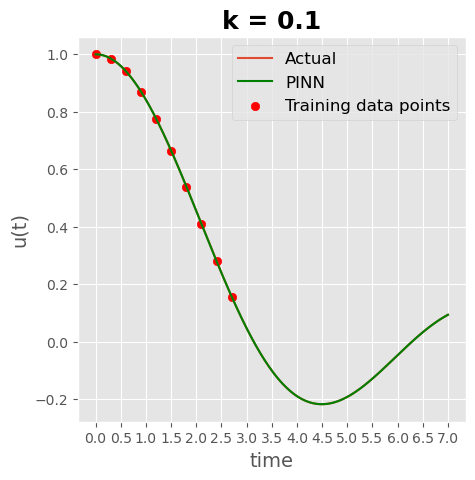

In [69]:
title_font = {"fontsize": 18, "fontweight": "bold"}

plt.figure(figsize=(5, 5))
plt.style.use("ggplot")
plt.xticks(np.arange(0, 7.5, step=0.5))
plt.title("k = 0.1", title_font)
plt.plot(x, y, label="Actual")
plt.xlabel("time", fontsize=14)
plt.plot(x, y_pred, label="PINN", c="g")
plt.ylabel("u(t)", fontsize=14)
plt.scatter(
    x_data.reshape(
        -1,
    ),
    y_data.reshape(
        -1,
    ),
    c="r",
    label="Training data points",
)
plt.legend(fontsize="large")
plt.show()

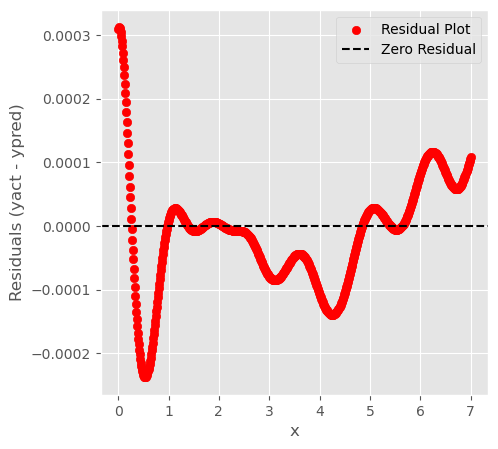

In [70]:
residuals = y - y_pred
plt.figure(figsize=(5, 5))
plt.scatter(x, residuals, color="r", label="Residual Plot")
plt.axhline(y=0, color="k", linestyle="--", label="Zero Residual")
plt.xlabel("x")
plt.ylabel("Residuals (yact - ypred)")
plt.legend()
plt.show()

<b>Research Paper's Error: 3.16 x 10^-9</b>
<br>
<b>Our Final Error: 4.92 x 10^-10</b>
